* [x] move lattice code to class
* [ ] add determination of specializer/generalizer; check implementation of specializer
* [ ] use KNN graph or graph from umap
* [ ] Set color to scenario ID
* [ ] Compute number of generalizers needed so that at least k specailizers exist per feature
* [ ] Function to determine best specialization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload 

In [2]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

# EDA Alternatives / Baselines

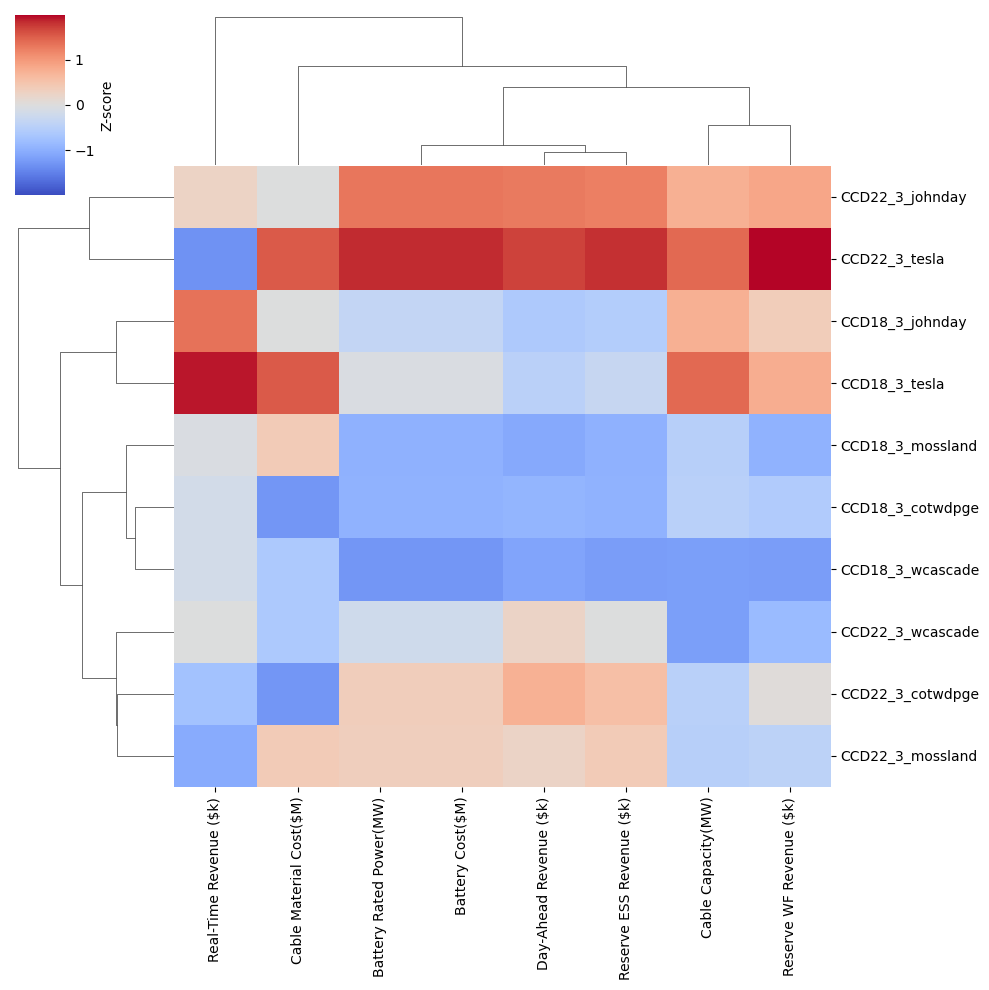

In [33]:
import seaborn as sns

df = df_design

X = (df - df.mean())/df.std()
vmax = vmax = X.abs().max().max()
vmin = -vmax
sns.clustermap(X, vmin=vmin, vmax=vmax, cmap='coolwarm', cbar_kws=dict(label='Z-score'))

# import matplotlib
# matplotlib.figure.Figure.colorbar.

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:2433: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


(5.064629554748535, 8.11528491973877, 5.856477999687195, 8.41555712223053)

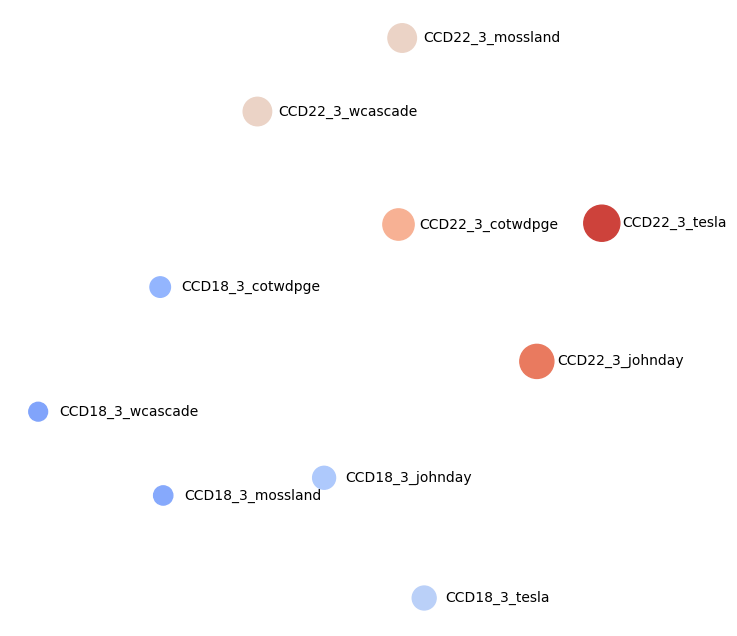

In [46]:
from umap import UMAP


plt.figure(figsize=(8, 8))

cmap = plt.cm.coolwarm
norm = plt.Normalize(-vmax, vmax)

pos = UMAP().fit_transform(X)
plt.scatter(*pos.T, s=df[by]/5, c=cmap(norm(X[by])))

for s, xy in zip(df.index, pos):
    plt.annotate(s, xy, va='center', xytext=(15, 0), textcoords='offset points')

plt.axis('off')


Cable Material Cost($M):  less --> more


<Figure size 800x800 with 0 Axes>

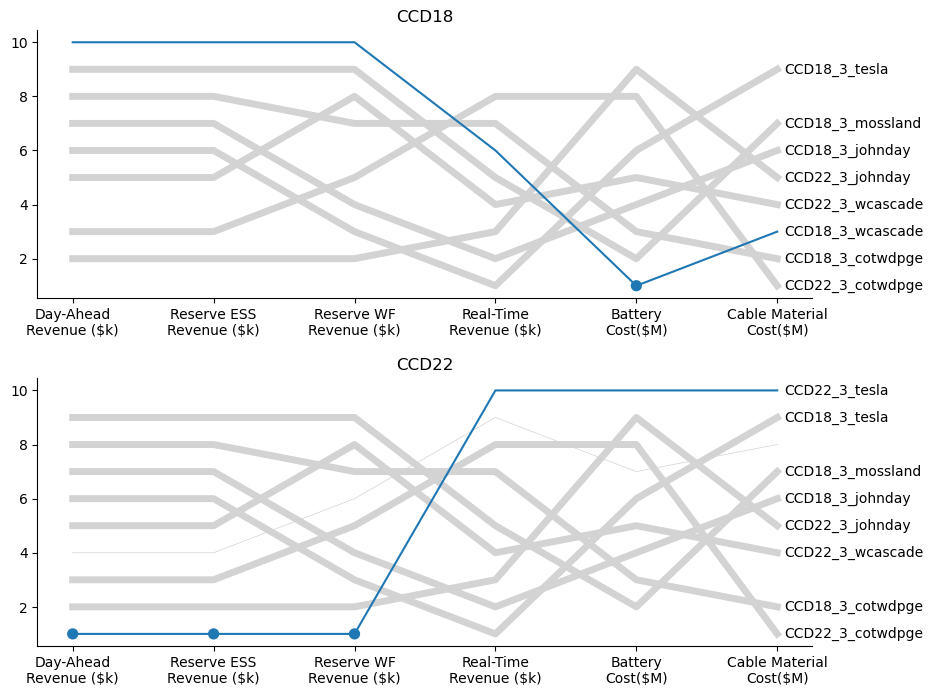

In [490]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending,
    # min_specializers=1,
    max_specializers=1,
    # n_generalizers=1,
)

by = ovars[0]

# plt.figure(figsize=(8, 8))
# plt.axis('off')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold'),
#     show_negative=True,
#     show_positive=False,
# )

# plt.title(f'{by}:  less --> more')
print(f'{by}:  less --> more')
plt.savefig('design_solutions_tradeoffs_v0.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 8))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.3)

# self.ovars_formatted()

In [491]:
self.specializers

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD18_3_wcascade,False,True,False,False,False,False
CCD22_3_tesla,False,False,True,False,True,True


# Larger Example

22 9


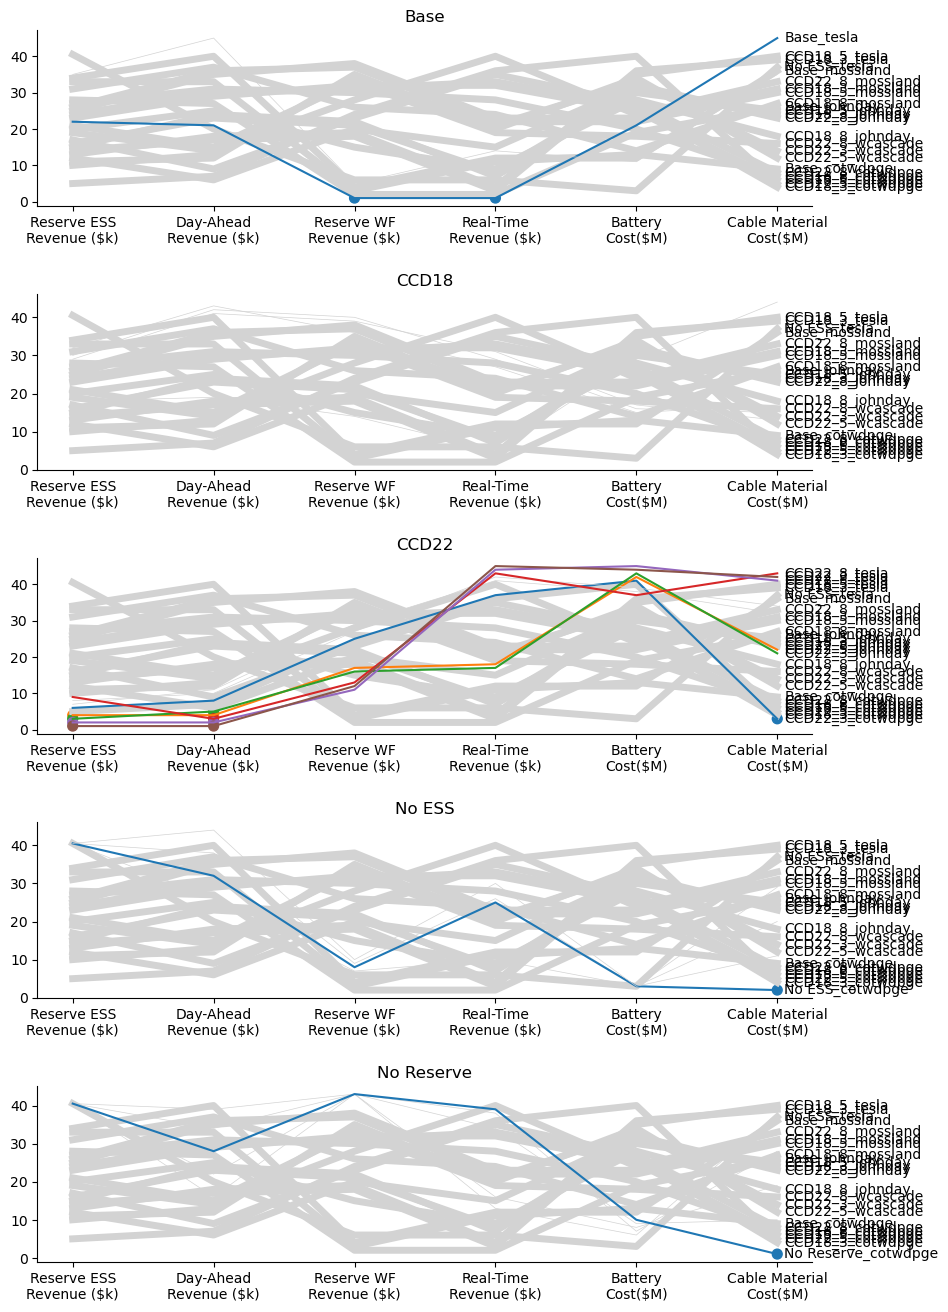

In [480]:
import tradeoff_lattice as tl; reload(tl)

df_design = pd.read_csv(os.path.join(path, 'design_solutions.csv'), index_col=0)

def get_cluster_name(s):
    parts = s.split('_')
    return '_'.join([parts[0], parts[-1]])
    
ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.DirectTradeoffLattice(
    df_design,
    ovars, dvars,
    ascending=ascending,
    max_specializers=5,
    # min_specializers=1,
    # n_generalizers=10,
)

by = ovars[0]

# plt.figure(figsize=(12, 24))
# plt.axis('off')
# plt.title(f'{by}:  less --> more')
# self.draw(
#     by=by,
#     node_size=500,
#     with_edge_labels=self.dvars,
#     edge_labels_kwargs=dict(font_size=6, rotate=False),
#     node_labels_kwargs=dict(fontsize=8, fontweight='bold')
# )

# plt.savefig('design_solutions_tradeoffs.pdf', format='pdf', bbox_inches='tight')

plt.figure(figsize=(10, 16))
self.plot_ovars_parallel_coords(
    x_label_format=ovar_format,
    facets = [
        i.split('_')[0]
        for i in self.rank.index
    ]
)

plt.subplots_adjust(hspace=.5)
print(self.n_generalizers, len(self.specializers))

In [481]:
self.specializers.sum(axis=0)

Cable Material Cost($M)     3
Battery Cost($M)            0
Day-Ahead Revenue ($k)      5
Real-Time Revenue ($k)      1
Reserve WF Revenue ($k)     1
Reserve ESS Revenue ($k)    4
dtype: int64

In [ ]:
df_control = pd.read_csv(os.path.join(path, 'control_data.csv'))\
    .set_index(['config', 'sim', 'time'])
df_control

In [ ]:
def calc_closest_factors(c):
    a, b, i = 1, c, 0
    while a < b:
        i += 1
        if c % i == 0:
            a = i
            b = c//a

    return max(b, a), min(b, a)

def best_dims(n, armax=1.5):
    def objective(x):
        a, b = x
        
        if a/b <= armax:
            y = a*b - n
        else:
            y = n

        return y
    
    return min(
        map(calc_closest_factors, range(n, n + int(n**.5))),
        key=objective
    )
    
best_dims(21)

In [ ]:
df = df_control.loc['CCD18_3_cotwdpge', 22]

s = 1
ncols, nrows = best_dims(len(df.columns))

plt.figure(figsize=(s*ar*ncols, s*nrows))

for i, c in enumerate(df):    
    df[c].plot(ax=plt.subplot(nrows, ncols, i + 1))
    plt.ylabel(c)
    plt.xlabel(None)
    plt.xticks([], [])
plt.subplots_adjust(wspace=.65)